In [1]:
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython import display
import matplotlib.pyplot as plt
import pandas as pd
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
coord = pd.read_csv('coordinates.csv', skiprows=1)

In [3]:
files = os.listdir('OUTPUT/')
circle_best_files=[]
circle_avg_files=[]
for file in files:
    if 'best_sol_circle' in file:
        circle_best_files.append(file)
        continue
    if 'avg_circle' in file:
        circle_avg_files.append(file)
        continue
        

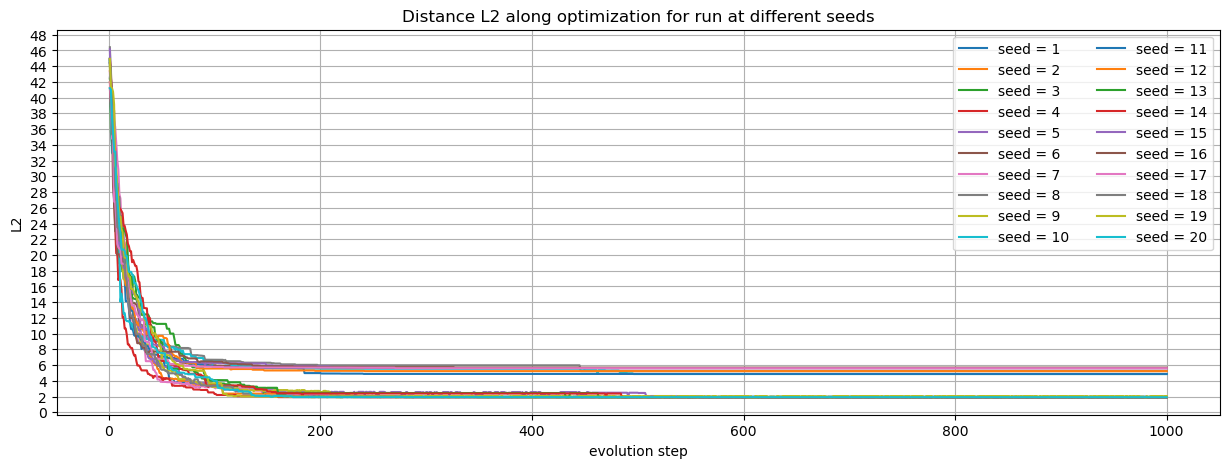

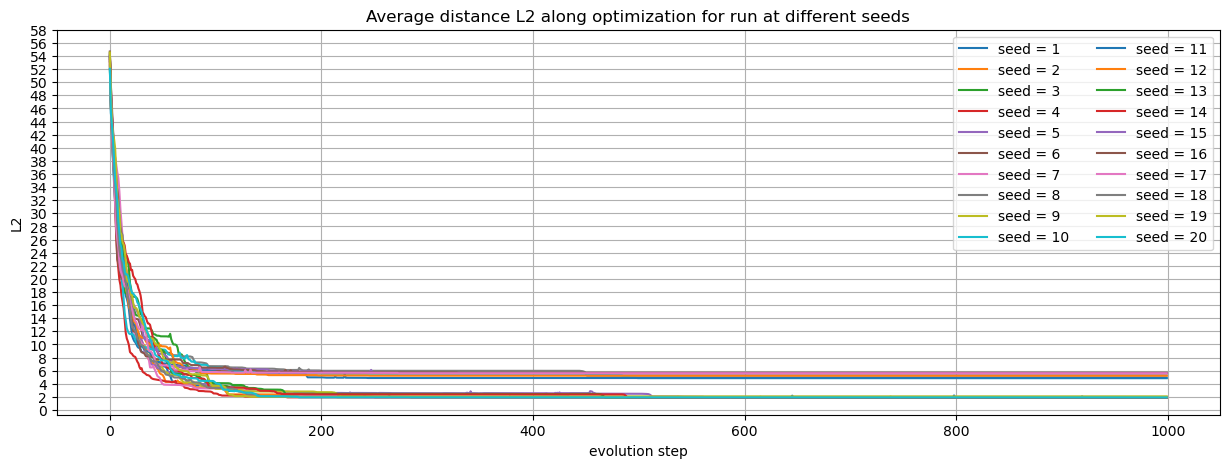

In [13]:
plt.figure(figsize=(15, 5))
plt.title('Distance L2 along optimization for run at different seeds')

bdists=[]

for file in circle_best_files:

    seed = file.split('seed')[1].split('.')[0]
    df_best = pd.read_csv('OUTPUT/'+file, names=[f'city{k}' for k in range(35)]+['dist'])

    bdists.append(df_best['dist'][len(df_best.index)-1])
    
    plt.plot(df_best.index, df_best['dist'], '-', label = "seed = "+seed) 
plt.yticks(range(0, 50, 2), range(0, 50, 2))
plt.ylabel('L2')
plt.xlabel('evolution step')
plt.grid()
plt.legend(ncols=2)
plt.savefig('OUTPUT/distances.png', dpi=300)
plt.show()


plt.figure(figsize=(15, 5))
plt.title('Average distance L2 along optimization for run at different seeds')
adist=[]


for file in circle_avg_files:

    seed = file.split('seed')[1].split('.')[0]
    df_avg = pd.read_csv('OUTPUT/'+file, names=['avg'], skiprows=1)
    adist.append(df_avg['avg'][len(df_avg.index)-1])
    
    plt.plot(df_avg.index, df_avg['avg'], '-', label = "seed = "+seed) 
plt.yticks(range(0, 60, 2), range(0, 60, 2))
plt.grid()
plt.legend(ncols=2)
plt.ylabel('L2')
plt.xlabel('evolution step')
plt.savefig('OUTPUT/avg_distances.png', dpi=300)
plt.show()

/tmp/ipykernel_5069/1118347135.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


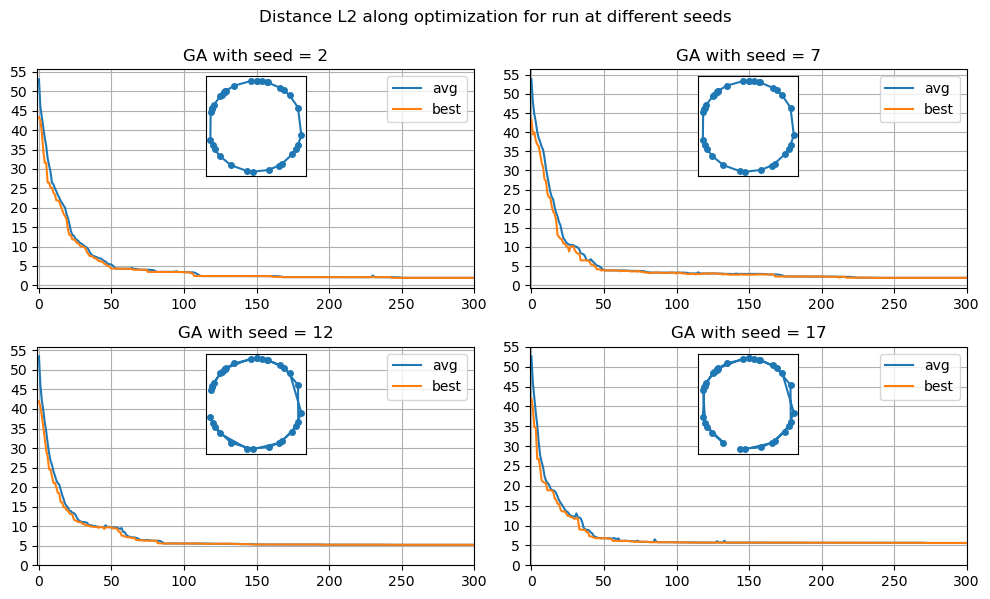

In [19]:
Nseed=20

n=2
fig, ax = plt.subplots(Nseed//(5*n), n, figsize=(5*n, 3*n))
fig.suptitle('Distance L2 along optimization for run at different seeds', y=0.99)



for ind, seed in enumerate(range(2,21, 5)):
    ax[ind//n, ind%n].set_title(f'GA with seed = {seed}')
    df_avg = pd.read_csv(f'OUTPUT/avg_circle_seed{seed}.dat', names=['avg'], skiprows=1)
    ax[ind//n, ind%n].plot(df_avg.index, df_avg['avg'], '-', label = f"avg") 

    df_best = pd.read_csv(f'OUTPUT/best_sol_circle_seed{seed}.dat', names=[f'city{k}' for k in range(35)]+['dist'], skiprows=1)
    ax[ind//n, ind%n].plot(df_best.index, df_best['dist'], '-', label = f"best") 

    ax[ind//n, ind%n].set_yticks(range(0, 60, 5), range(0, 60, 5))
    ax[ind//n, ind%n].grid()
    ax[ind//n, ind%n].legend()
    ax[ind//n, ind%n].set_xlim([-1, 300])
   
    sub_ax = inset_axes(
        parent_axes=ax[ind//n, ind%n],
        width=1,#"40%",
        height=1,#"40%",
        loc='upper center',
        borderpad=0.5  # padding between parent and inset axes
    )

    x=np.array([coord.iloc[int(k)-1].x for k in df_best.iloc[len(df_best)-1][:-1].array])
    y=np.array([coord.iloc[int(k)-1].y for k in df_best.iloc[len(df_best)-1][:-1].array])

    sub_ax.plot(x, y, '-o', ms=4)
    sub_ax.get_xaxis().set_visible(False)
    sub_ax.get_yaxis().set_visible(False)
plt.savefig('OUTPUT/seed_distances.png', dpi=300)
plt.tight_layout()
plt.show()

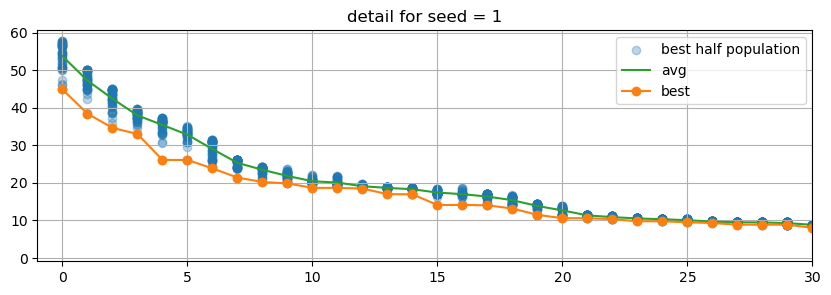

In [15]:
half =  pd.read_csv('OUTPUT/half_cost1.dat', names=['it']+[f'c{k}' for k in range(50)])
avg = pd.read_csv('OUTPUT/avg_circle_seed1.dat', names=['avg'], skiprows=1)
best = pd.read_csv('OUTPUT/best_sol_circle_seed1.dat', names=[f'city{k}' for k in range(35)]+['dist'], skiprows=1)
#half
plt.figure(figsize=(10, 3))
sc = [plt.scatter(half.it, half[f'c{k}'], c=f'C0', alpha=0.3)for k in range(50)]
plt.plot(avg['avg'], label='avg', c='C2')
plt.plot(best['dist'], '-o', label='best', c='C1')
plt.xlim([-1, 30])
plt.title('detail for seed = 1')
sc[-1].set_label('best half population')
plt.legend()
plt.grid()
plt.show()

Scrivere qualcosa commentando e mettendo link codice per creare gif [codice gif](animation.py)

Esempio di una run che finisce trovando effettivamente il minimo assoluto e una che si incastra in minimo locale


![SegmentLocal](OUTPUT/animation_circle_seed1.gif "segment")
![SegmentLocal](OUTPUT/animation_circle_seed6.gif "segment")

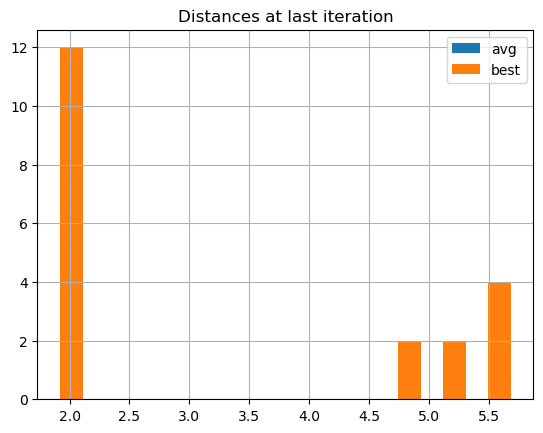

In [10]:
plt.title('Distances at last iteration')
plt.hist(adist, 20, label='avg')
plt.hist(bdists, 20, label='best')
plt.grid()
plt.legend()
plt.show()